# Projet OPER60500 - Prévision de la demande
## ITEM001 et ITEM002 - Matériel électrique

Ce notebook développe un outil de prévision de la demande pour deux produits make-to-stock
et le compare à la méthode actuelle de la compagnie (moyenne mobile 12 mois).

**Données :** rapport ERP de mouvements de stock, janvier 2022 à mai 2026.

**Structure :**
1. **Étape 1 :** Préparation des données (traitement CSV, nettoyage, graphiques)
2. **Étape 2 :** Prévision et évaluation (7 modèles testés sur janvier-mai 2026)
3. **Étape 3 :** Prévision finale (juin-décembre 2026) + niveaux de stock

**Stratégie de validation :** les données réelles de janvier à mai 2026 servent de
période de test hors-échantillon. Les modèles sont entrainés sur 2022-2025 puis testés
sur ces 5 mois réels.

#### Installation

In [ ]:
!pip install darts statsforecast prophet seaborn pytorch-lightning torch

print("Installation terminée.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.8/808.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### Imports

In [ ]:
import os, io, time, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

import darts
from darts import TimeSeries
from darts.models import (
    NaiveSeasonal, ExponentialSmoothing, Theta,
    AutoARIMA, Prophet, NaiveEnsembleModel, Croston
)
from darts.utils.utils import SeasonalityMode
from darts.metrics import mape, wmape, rmsse, rmse, merr

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"darts {darts.__version__} | pandas {pd.__version__}")

darts 0.45.0 | pandas 2.2.2


---
# Étape 1 : Préparation des données

Deux fichiers CSV (un pour chaque item), colonnes séparées par des points-virgules, avec des nombres au
format francais (virgule décimale, espace comme séparateur de milliers).

#### Upload du fichier CSV

In [ ]:
FICHIER_CSV_001 = "https://raw.githubusercontent.com/hr044/Donnees-projet/refs/heads/main/Mouvements_ITEM001.csv"
FICHIER_CSV_002 = "https://raw.githubusercontent.com/hr044/Donnees-projet/refs/heads/main/Mouvements_ITEM002.csv"

print(f"ITEM001 : {FICHIER_CSV_001}")
print(f"ITEM002 : {FICHIER_CSV_002}")

ITEM001 : https://raw.githubusercontent.com/hr044/Donnees-projet/refs/heads/main/Mouvements_ITEM001.csv
ITEM002 : https://raw.githubusercontent.com/hr044/Donnees-projet/refs/heads/main/Mouvements_ITEM002.csv


#### Paramètres de traitement CSV

In [ ]:
COLS = {
    "ITEM001": {"date": 0, "type": 3, "qin": 5, "qout": 7},
    "ITEM002": {"date": 0, "type": 3, "qin": 5, "qout": 7},
}

TX_TYPES = ["Receipt", "Shipment", "Credit Note", "Assm. Master"]
FREQ     = "MS"
DATE_MIN = "2022-01-01"
DATE_MAX = "2026-05-31"

def to_num(s):
    """Convertit un nombre au format francais en float : '1 539,36' => 1539.36"""
    if pd.isna(s):
        return np.nan
    return float(str(s).replace("\xa0", "").replace(" ", "").replace(",", "."))

print("Paramètres définis")

Paramètres définis


#### Fonction de traitement CSV

In [ ]:
def parser_produit(df, item_name, c):
    """
    Extrait les ventes mensuelles nettes d'un produit depuis le CSV d'origine.
    Shipment = vente, Credit Note = retour soustrait, Receipt/Assm. ignorés.
    Retourne (serie_mensuelle, rapport_qualite).
    """
    sub = df[[c["date"], c["type"], c["qin"], c["qout"]]].copy()
    sub.columns = ["date", "type", "qin", "qout"]
    sub = sub[sub["type"].isin(TX_TYPES)]
    sub["date"] = pd.to_datetime(sub["date"], format="%m/%d/%Y", errors="coerce")
    sub = sub.dropna(subset=["date"]).sort_values("date")
    sub["qin"]  = sub["qin"].apply(to_num).fillna(0)
    sub["qout"] = sub["qout"].apply(to_num).fillna(0)

    ship = sub[sub["type"] == "Shipment"].copy()
    ret  = sub[sub["type"] == "Credit Note"].copy()
    asm  = sub[sub["type"] == "Assm. Master"]

    rapport = {
        "item": item_name,
        "plage": f"{sub['date'].min().date()} -> {sub['date'].max().date()}",
        "nb_expeditions": len(ship),
        "unites_vendues": int(ship["qout"].sum()),
        "nb_retours": len(ret),
        "unites_retours": int(ret["qin"].sum()),
        "nb_assemblages": len(asm),
    }

    # Ventes brutes mensuelles
    ship["mois"] = ship["date"].dt.to_period("M").dt.to_timestamp()
    ventes = ship.groupby("mois")["qout"].sum()

    # Soustraire les retours
    if len(ret) > 0:
        ret["mois"] = ret["date"].dt.to_period("M").dt.to_timestamp()
        ventes = ventes.subtract(ret.groupby("mois")["qin"].sum(), fill_value=0).clip(lower=0)

    # Index mensuel complet
    idx = pd.date_range(DATE_MIN, DATE_MAX, freq=FREQ)
    serie = ventes.reindex(idx, fill_value=0).rename(item_name)

    rapport["nb_mois"]        = len(serie)
    rapport["mois_a_zero"]    = int((serie == 0).sum())
    rapport["demande_totale"] = int(serie.sum())
    rapport["demande_moy"]    = round(float(serie.mean()), 1)
    return serie, rapport

print("Fonction définie")

Fonction définie


#### Chargement et nettoyage

In [ ]:
series_dict = {}
rapports    = []

for item_name, fichier in [("ITEM001", FICHIER_CSV_001), ("ITEM002", FICHIER_CSV_002)]:
    df_raw = pd.read_csv(fichier, sep=";", header=None, dtype=str, skiprows=[0])
    serie, rapport = parser_produit(df_raw, item_name, COLS[item_name])
    series_dict[item_name] = serie
    rapports.append(rapport)
    print(f"\n{item_name}")
    print(f"  Plage          : {rapport['plage']}")
    print(f"  Expéditions    : {rapport['nb_expeditions']} | {rapport['unites_vendues']} unités")
    print(f"  Retours        : {rapport['nb_retours']} | {rapport['unites_retours']} unités soustraites")
    print(f"  Assemblages    : {rapport['nb_assemblages']} (ignores)")
    print(f"  Mois à 0 vente : {rapport['mois_a_zero']} / {rapport['nb_mois']}")
    print(f"  Demande totale : {rapport['demande_totale']} u | moy {rapport['demande_moy']} u/mois")

# Assembler le DataFrame final
data = pd.DataFrame(series_dict)
data.index.name = "ds"
items = list(data.columns)

data.to_csv(os.path.join(OUTPUT_DIR, "donnees_mensuelles.csv"))
pd.DataFrame(rapports).to_csv(os.path.join(OUTPUT_DIR, "rapport_qualite.csv"), index=False)
print(f"\n{len(data)} mois x {len(items)} produits sauvegardés")


ITEM001
  Plage          : 2022-03-03 -> 2026-05-13
  Expéditions    : 100 | 3474 unités
  Retours        : 4 | 8 unités soustraites
  Assemblages    : 0 (ignores)
  Mois à 0 vente : 9 / 53
  Demande totale : 3466 u | moy 65.4 u/mois

ITEM002
  Plage          : 2022-01-13 -> 2026-05-28
  Expéditions    : 104 | 2957 unités
  Retours        : 0 | 0 unités soustraites
  Assemblages    : 2 (ignores)
  Mois à 0 vente : 6 / 53
  Demande totale : 2957 u | moy 55.8 u/mois

53 mois x 2 produits sauvegardés


#### Aperçu des données récentes (2025-2026)

In [ ]:
display(data[data.index.year >= 2025])

,ITEM001,ITEM002
ds,,
2025-01-01,108.0,228.0
2025-02-01,96.0,152.0
2025-03-01,24.0,104.0
2025-04-01,180.0,232.0
2025-05-01,180.0,64.0
2025-06-01,84.0,78.0
2025-07-01,120.0,112.0
2025-08-01,0.0,12.0
2025-09-01,108.0,12.0


#### Graphique - Séries temporelles

Les mois de 2026 réels (janvier-mai) sont mis en evidence.

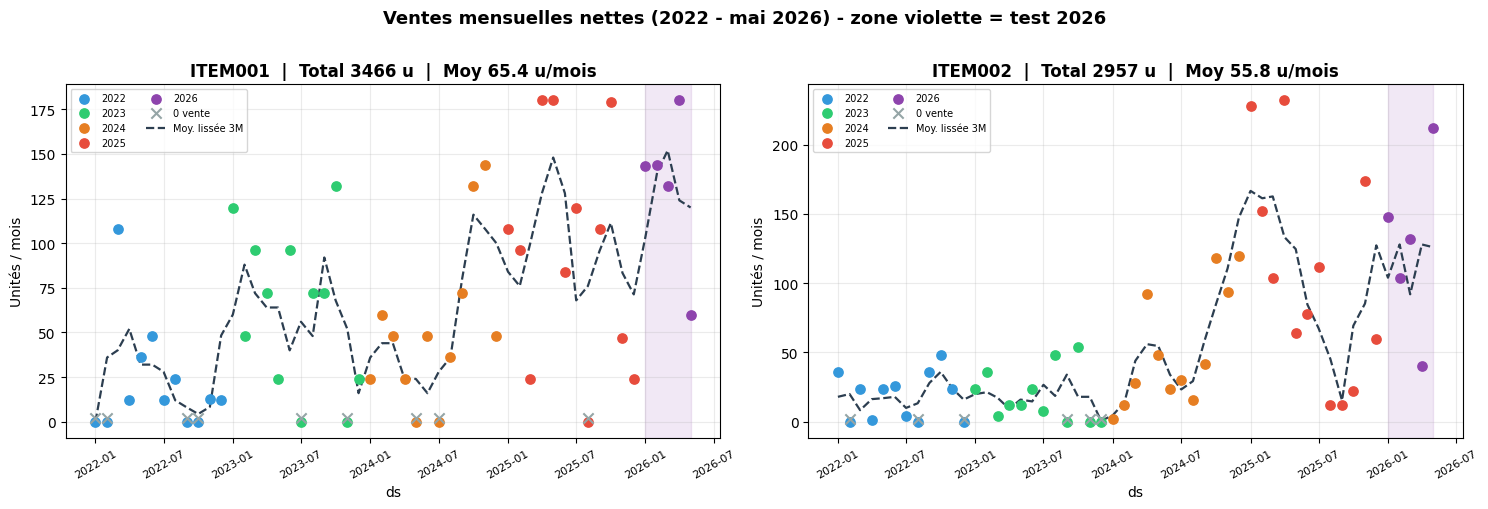

In [ ]:
palette_annees = {2022:"#3498db", 2023:"#2ecc71", 2024:"#e67e22", 2025:"#e74c3c", 2026:"#8e44ad"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, item in enumerate(items):
    ax = axes[i]
    y  = data[item]
    for annee, couleur in palette_annees.items():
        m = y.index.year == annee
        if m.any():
            ax.scatter(y.index[m], y[m], color=couleur, s=45, label=str(annee), zorder=3)
    zm = y == 0
    ax.scatter(y.index[zm], [2]*zm.sum(), color="#95a5a6", marker="x", s=55, zorder=4, label="0 vente")
    sns.lineplot(x=y.index, y=y.rolling(3, center=True, min_periods=1).mean(),
                 ax=ax, color="#2c3e50", linewidth=1.6, linestyle="--", label="Moy. lissée 3M")
    # Zone de test 2026
    ax.axvspan(pd.Timestamp("2026-01-01"), pd.Timestamp("2026-05-01"),
               alpha=0.12, color="#8e44ad")
    ax.set_title(f"{item}  |  Total {y.sum():.0f} u  |  Moy {y.mean():.1f} u/mois",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Unités / mois")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=7, loc="upper left", ncol=2)
    ax.grid(True, alpha=0.25)
plt.suptitle("Ventes mensuelles nettes (2022 - mai 2026) - zone violette = test 2026",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "series.png"), dpi=150, bbox_inches="tight")
plt.show()

#### Graphique - Volume annuel

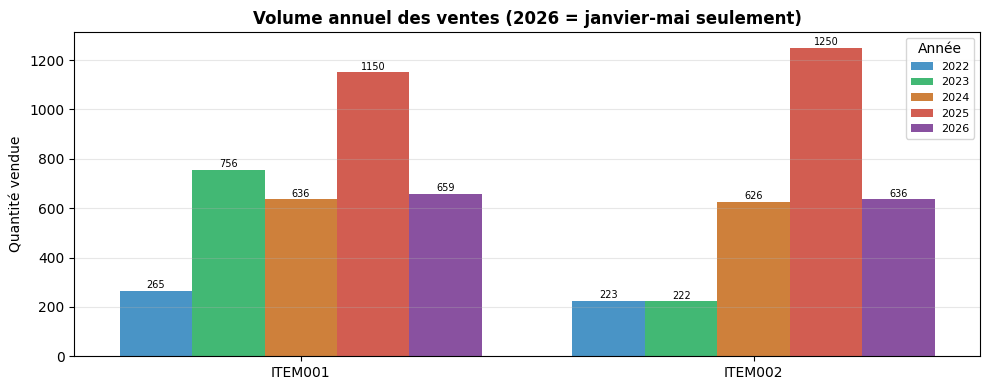

In [ ]:
donnees_ann = []
for item in items:
    for annee in [2022, 2023, 2024, 2025, 2026]:
        donnees_ann.append({"Produit": item, "Année": str(annee),
                            "Total": data.loc[data.index.year == annee, item].sum()})
df_ann = pd.DataFrame(donnees_ann)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_ann, x="Produit", y="Total", hue="Année",
            palette=list(palette_annees.values()), ax=ax)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x()+p.get_width()/2, h+3, f"{h:.0f}", ha="center", va="bottom", fontsize=7)
ax.set_title("Volume annuel des ventes (2026 = janvier-mai seulement)", fontsize=12, fontweight="bold")
ax.set_ylabel("Quantité vendue")
ax.set_xlabel("")
ax.legend(title="Année", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "volumes.png"), dpi=150, bbox_inches="tight")
plt.show()

---
# Étape 2 : Prévision et évaluation des modèles

**Validation :** entraînement sur 2022-2025 (48 mois), test sur janvier-mai 2026
(5 mois réels). Validation hors-échantillon puisque ces mois
n'ont pas servi à l'entraînement.

**Modèles testés :**
- NaiveSeasonal : répète la valeur du même mois l'an dernier
- ExponentialSmoothing : lissage exponentiel (tendance + saisonnalité)
- Theta : décomposition (mode additif, robuste aux zéros)
- AutoARIMA : sélection automatique des paramètres
- Prophet : modèle hybride Facebook
- Croston : spécialisé demande intermittente
- NaiveEnsembleModel : moyenne de NaiveSeasonal + Theta + Croston
- MM12 : moyenne mobile 12 mois (méthode actuelle, référence)

**Métriques :** wMAPE et RMSSE (robustes aux mois à zero). RMSSE < 1 signifie que le modèle bat la prevision naïve de référence.

#### Fonctions du pipeline

In [ ]:
TEST_N_POINTS = 5    # janvier-mai 2026

def mm12_prevision(train_series, n):
    """Baseline : dernière moyenne mobile 12 mois répétée sur n mois."""
    mm = train_series.rolling(12, min_periods=1).mean().iloc[-1]
    idx = pd.date_range(start=train_series.index[-1] + pd.DateOffset(months=1),
                        periods=n, freq=FREQ)
    return pd.Series(mm, index=idx, name="MM12")


def calculate_test_errors(test_series, forecast_series, train_series,
                           series_name="y", skip_mape=False):
    """
    Calcule les erreurs hors-échantillon.
    wMAPE toujours calculé (robuste aux zeros), MAPE=NaN si zéros dans test.
    """
    m_name   = forecast_series.name
    common   = test_series.index.intersection(forecast_series.index)
    ts_test  = TimeSeries.from_series(test_series[common])
    ts_fcst  = TimeSeries.from_series(forecast_series[common])
    ts_train = TimeSeries.from_series(train_series)

    m_rmsse   = rmsse(ts_test, ts_fcst, insample=ts_train)
    m_rmse_v  = rmse(ts_test, ts_fcst)
    m_merr_v  = merr(ts_test, ts_fcst)
    test_mean = test_series[common].mean()

    try:    m_wmape = wmape(ts_test, ts_fcst)
    except: m_wmape = np.nan
    m_mape = np.nan
    if not skip_mape:
        try:    m_mape = mape(ts_test, ts_fcst)
        except: pass

    cols = ["SeriesName","Model","MAPE","wMAPE","RMSSE","RMSE","Norm_RMSE","ME","Norm_ME"]
    row  = [series_name, m_name, m_mape, m_wmape, m_rmsse, m_rmse_v,
            m_rmse_v/test_mean if test_mean else np.nan,
            m_merr_v, m_merr_v/test_mean if test_mean else np.nan]
    return pd.DataFrame([row], columns=cols)


def plot_forecasts(df_forecasts, series_name, test_start):
    """Graphique : réel + toutes les prévisions."""
    plt.figure(figsize=(16, 5))
    plt.title(f"Comparaison des modèles - {series_name} (test janvier-mai 2026)")
    y = df_forecasts["y"]
    sns.scatterplot(x=y.index, y=y.values, color="#2c3e50", s=40, label="Reel", zorder=5)
    couleurs = ["#e74c3c","#3498db","#9b59b6","#e67e22","#27ae60","#1abc9c","#f39c12","#c0392b"]
    for j, col in enumerate(df_forecasts.columns[1:]):
        sns.lineplot(data=df_forecasts[col].dropna(), label=col,
                     color=couleurs[j % len(couleurs)], linewidth=1.8)
    plt.axvspan(test_start, y.index[-1], alpha=0.08, color="#8e44ad")
    plt.axvline(test_start, color="gray", linestyle=":", linewidth=1.5)
    plt.ylabel("Unités / mois")
    plt.legend(fontsize=7)
    plt.tight_layout()


def plot_modele_individuel(y, fcst, series_name, modele_nom, test_start, couleur):
    """Graphique individuel pour analyser 1 modèle seul."""
    plt.figure(figsize=(16, 4))
    plt.title(f"{series_name} - {modele_nom}")
    sns.scatterplot(x=y[-30:].index, y=y[-30:].values, color="#2c3e50", s=35, label="Réel", zorder=5)
    sns.lineplot(data=fcst.dropna(), label=modele_nom, color=couleur, linewidth=2, linestyle="--")
    plt.axvline(test_start, color="gray", linestyle=":", linewidth=1.2, label="Début test 2026")
    plt.ylabel("Unités / mois")
    plt.legend(fontsize=8)
    plt.tight_layout()

print("Fonctions définies")

Fonctions définies


#### Définition des modèles

In [ ]:
ensemble_sub = [
    NaiveSeasonal(K=12),
    Theta(season_mode=SeasonalityMode.ADDITIVE),
    Croston(),
]
list_models = [
    NaiveSeasonal(K=12),
    ExponentialSmoothing(),
    Theta(season_mode=SeasonalityMode.ADDITIVE),
    AutoARIMA(),
    Prophet(),
    Croston(),
    NaiveEnsembleModel(forecasting_models=ensemble_sub, show_warnings=False),
]
print("Modèles :", [str(m)[:25] for m in list_models])

Modèles : ['NaiveSeasonal(K=12)', 'ExponentialSmoothing()', 'Theta(season_mode=Seasona', 'AutoARIMA()', 'Prophet()', 'Croston()', 'NaiveEnsembleModel(show_w']


#### Boucle sur les deux produits
Pour chaque produit : séparation train/test, entraînement de chaque modèle,
calcul des métriques, graphique combine, puis un graphique individuel par modèle.


  ITEM001  (53 mois | 9 mois à 0)
  NaiveSeasonal(K=12)...  ok (0.0s)
  ExponentialSmoothing()...  ok (0.6s)
  Theta(season_mode=Seasona...  ok (0.1s)
  AutoARIMA()...  ok (3.0s)
  Prophet()...  

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


ok (1.8s)
  Croston()...  ok (6.3s)
  NaiveEnsembleModel(show_w...  ok (0.1s)

  Résultats ITEM001 (tri par RMSSE) :


,Model,MAPE,wMAPE,RMSSE,RMSE
0,Prophet(),30.562034,25.209730,0.583289,38.294981
1,ExponentialSmoothing(),34.663601,28.158023,0.620306,40.725261
2,AutoARIMA(),40.385375,36.368052,0.766332,50.312367
3,MM12,40.062646,38.163885,0.812305,53.330677
4,Theta(season_mode=Seasona,38.894942,39.319513,0.839637,55.125082
5,NaiveEnsembleModel(show_w,50.254850,44.389896,0.898812,59.010129
6,Croston(),43.944199,46.657459,1.025653,67.337695
7,NaiveSeasonal(K=12),67.925408,47.192716,1.171795,76.932438


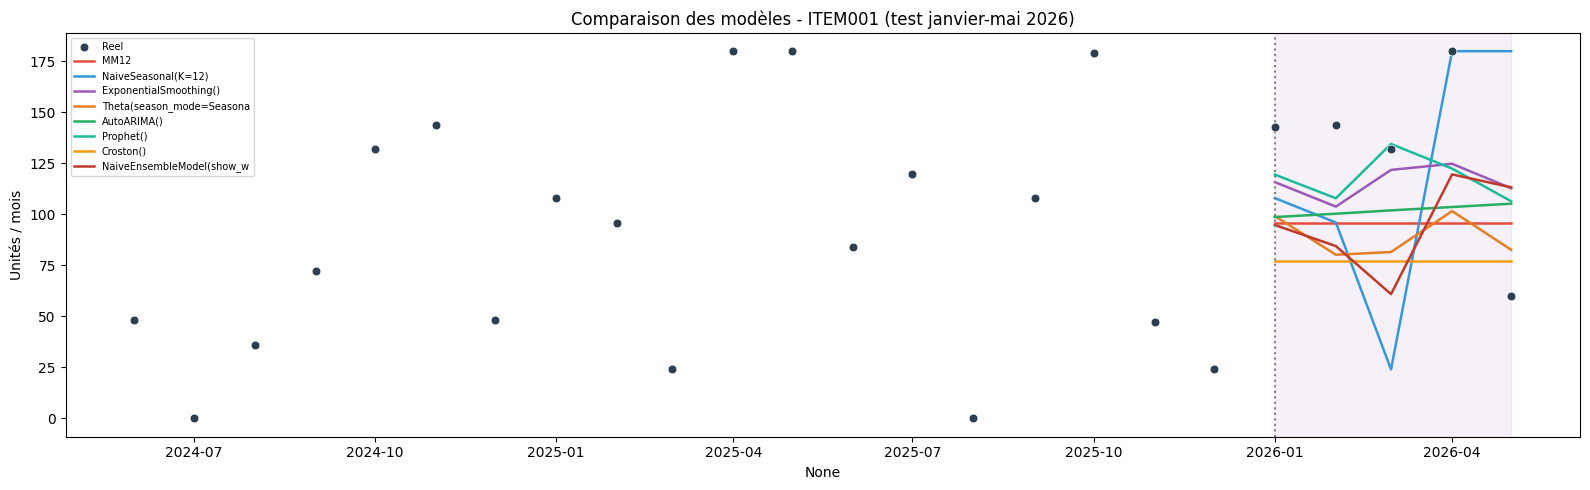


  Graphiques individuels - ITEM001 :


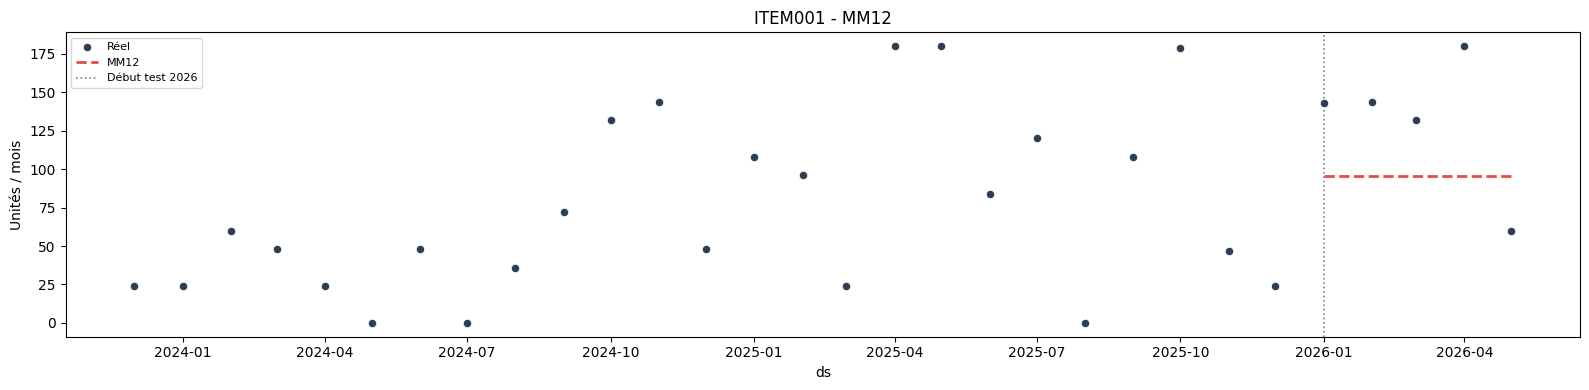

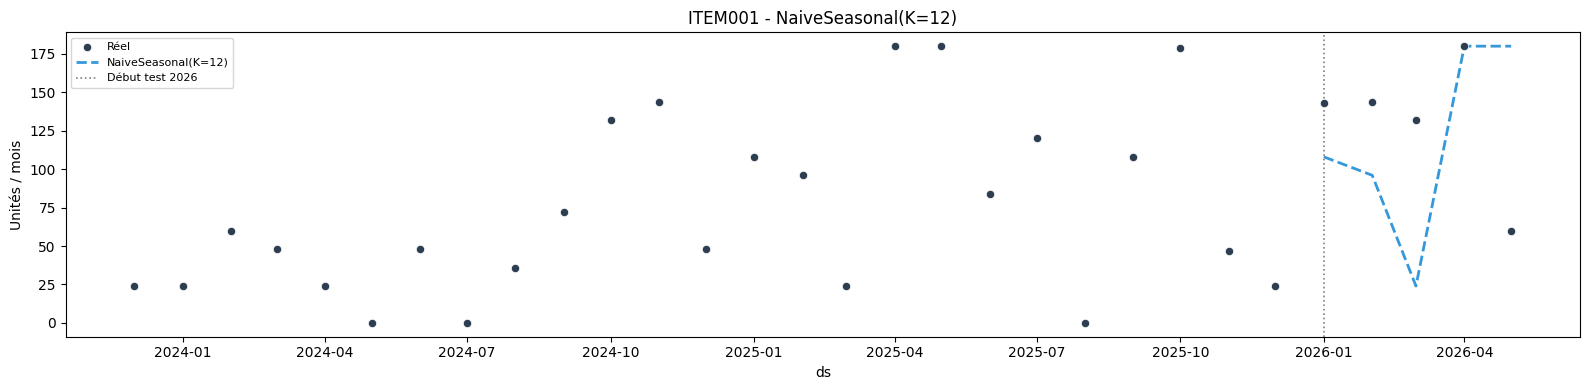

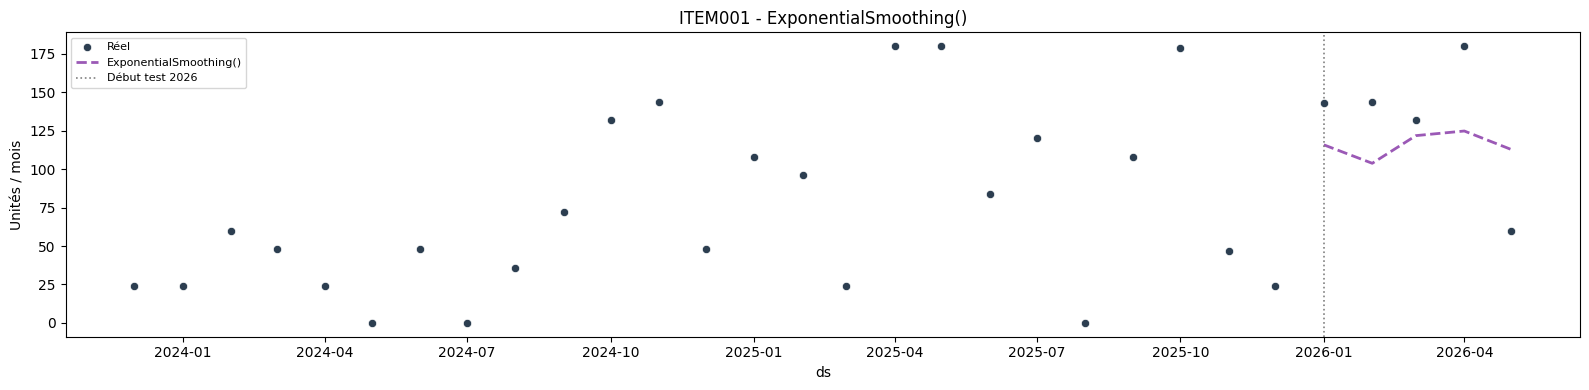

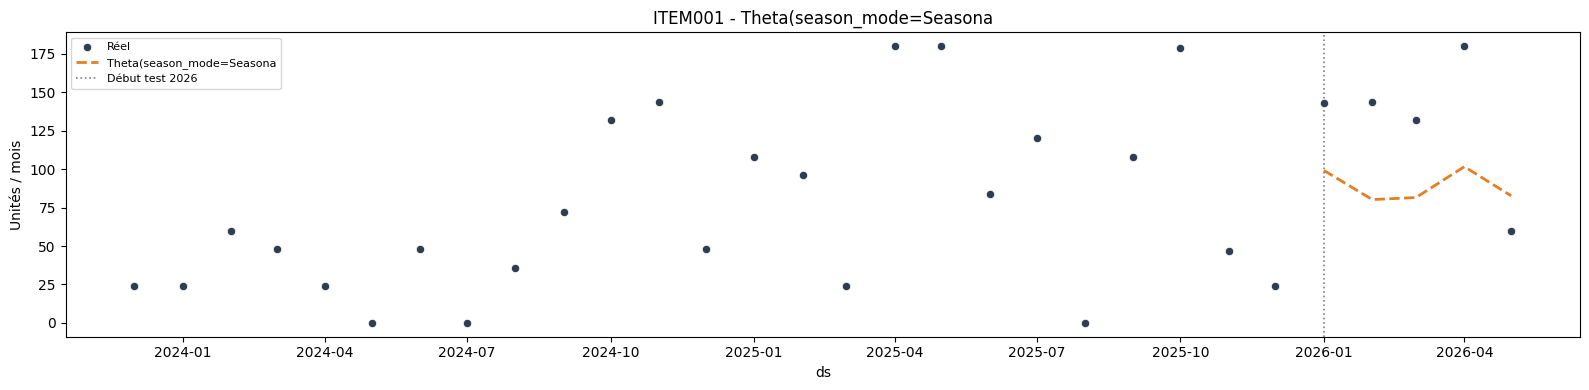

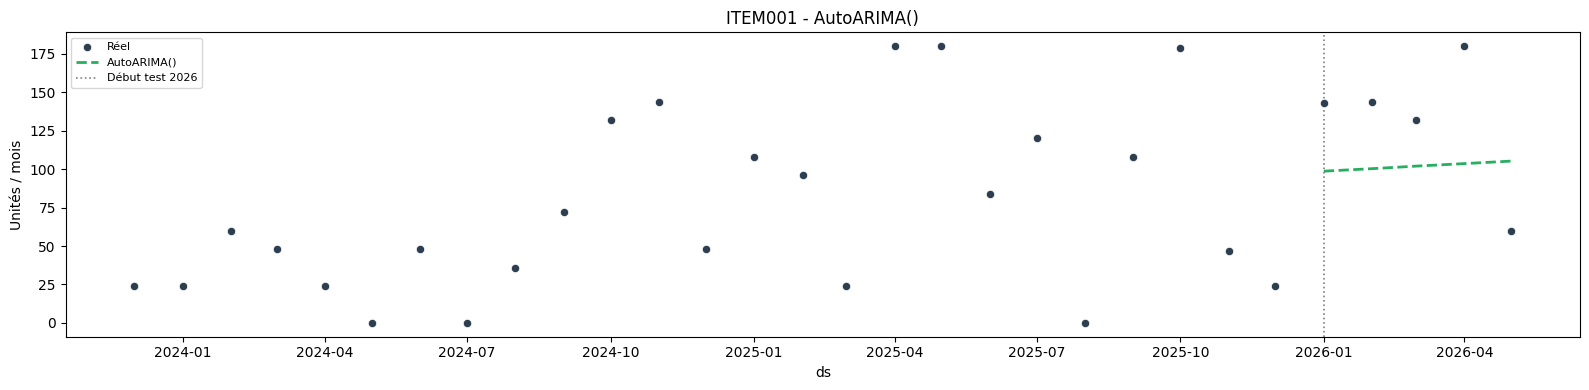

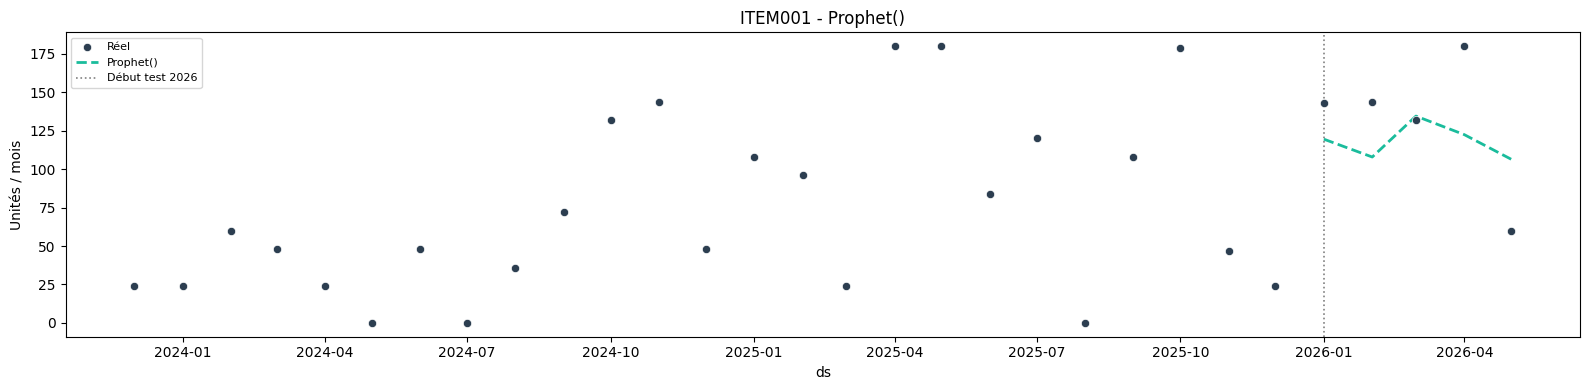

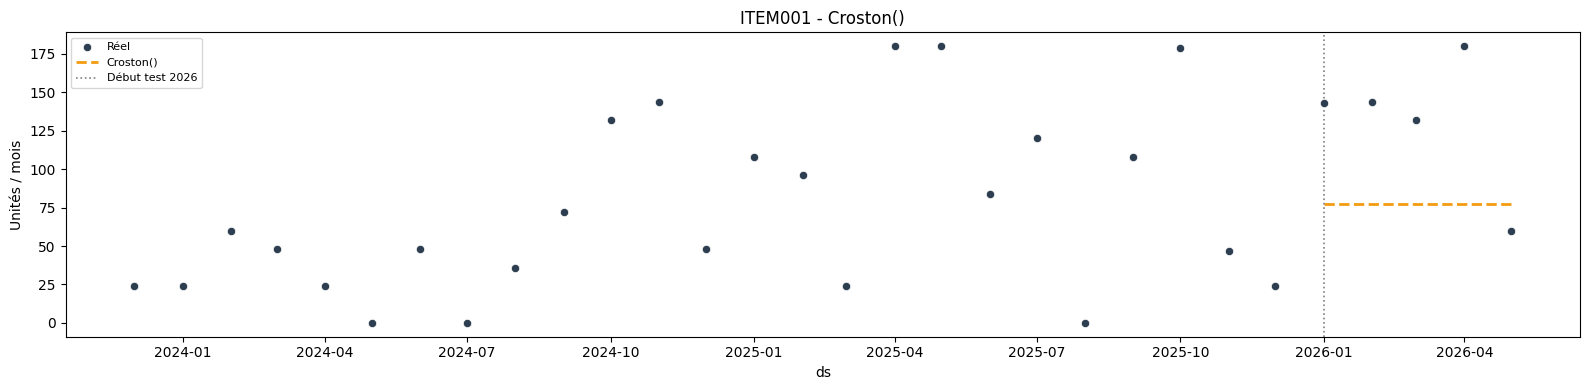

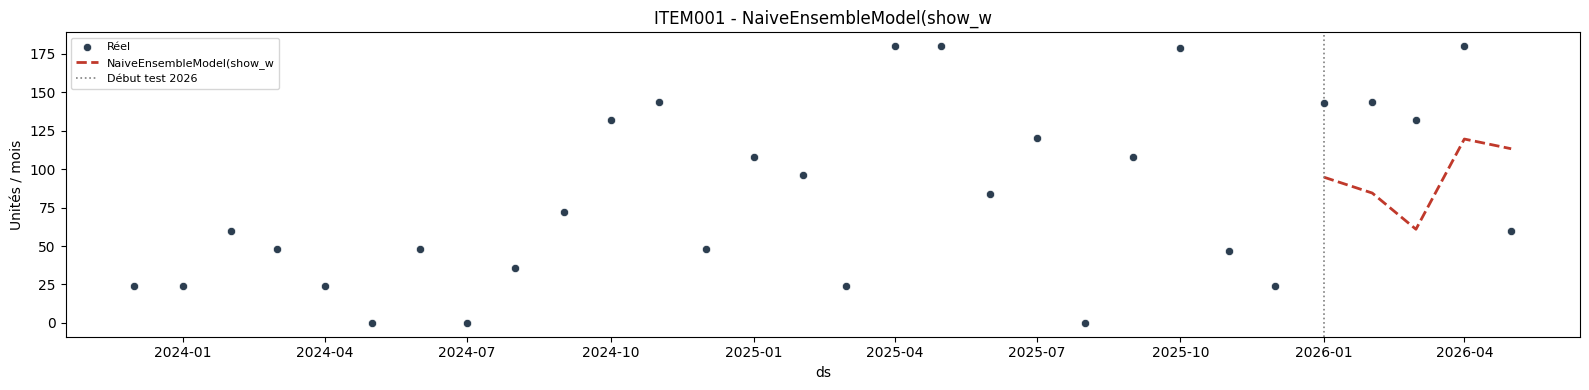


  ITEM002  (53 mois | 6 mois à 0)
  NaiveSeasonal(K=12)...  ok (0.0s)
  ExponentialSmoothing()...  ok (0.2s)
  Theta(season_mode=Seasona...  ok (0.0s)
  AutoARIMA()...  

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


ok (0.5s)
  Prophet()...  ok (0.5s)
  Croston()...  ok (0.0s)
  NaiveEnsembleModel(show_w...  ok (0.0s)

  Résultats ITEM002 (tri par RMSSE) :


,Model,MAPE,wMAPE,RMSSE,RMSE
0,MM12,52.428936,38.338574,1.094235,60.731330
1,Prophet(),69.539490,38.148030,1.211547,67.242329
2,Theta(season_mode=Seasona,63.092253,48.742356,1.280859,71.089224
3,ExponentialSmoothing(),69.427771,45.275225,1.317924,73.146343
4,AutoARIMA(),54.203348,50.117710,1.332931,73.979252
5,Croston(),54.299641,50.737389,1.348446,74.840351
6,NaiveEnsembleModel(show_w,70.770140,45.944410,1.403463,77.893873
7,NaiveSeasonal(K=12),134.246268,77.987421,2.105150,116.838350


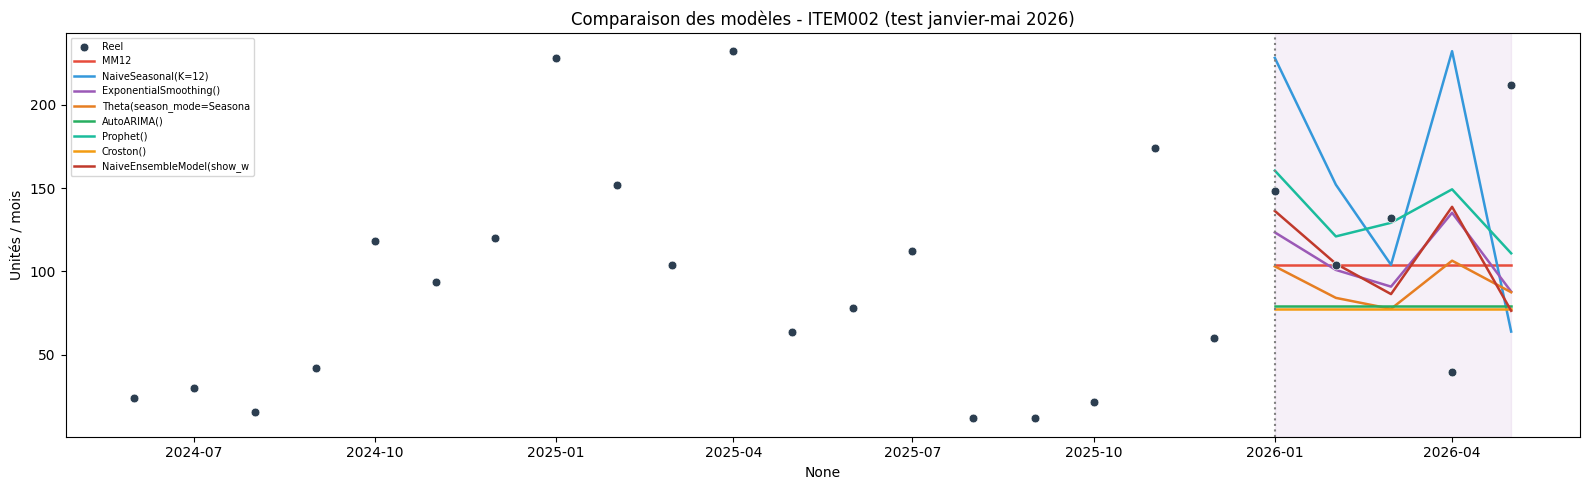


  Graphiques individuels - ITEM002 :


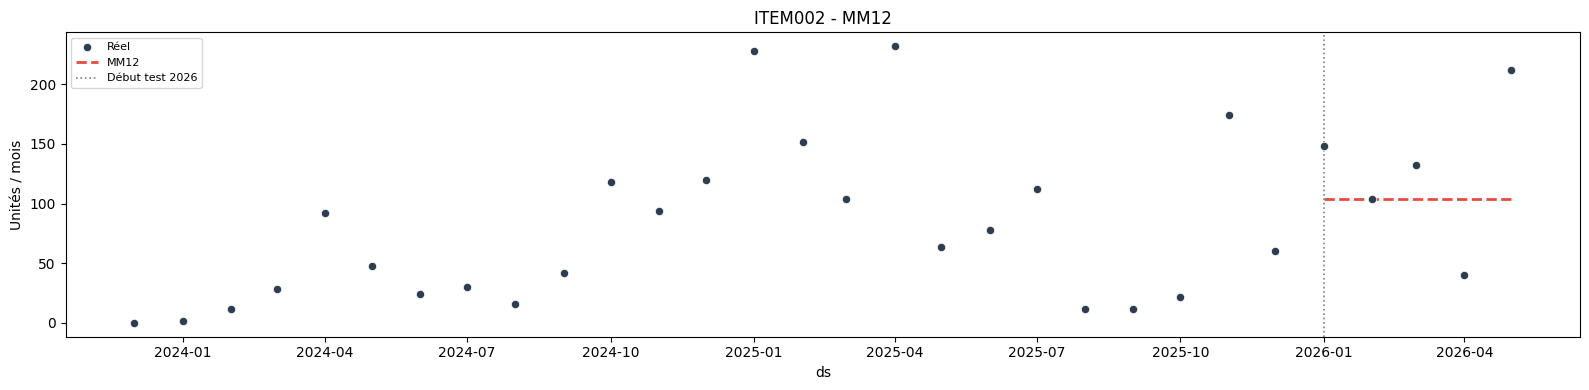

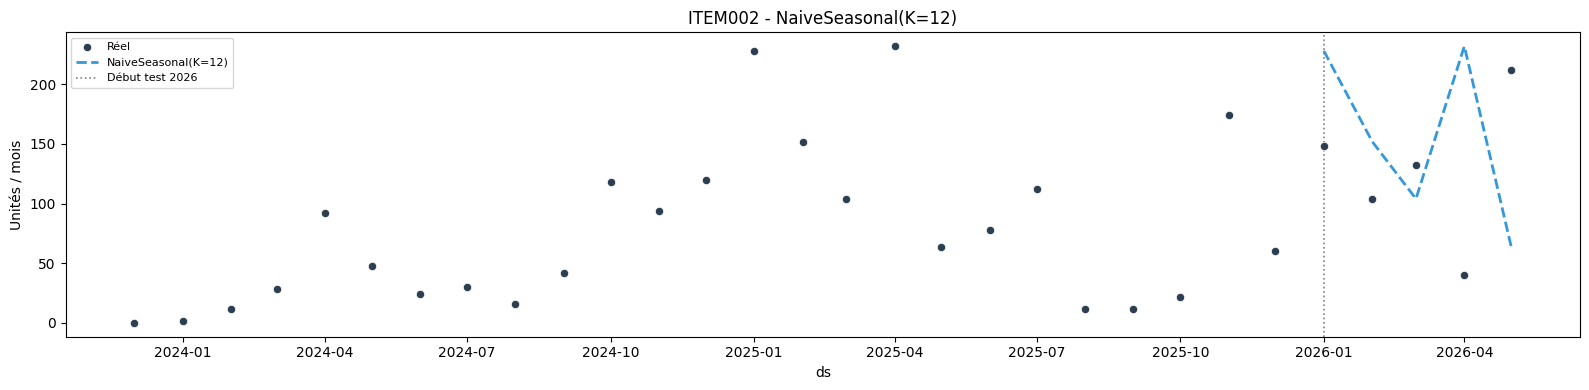

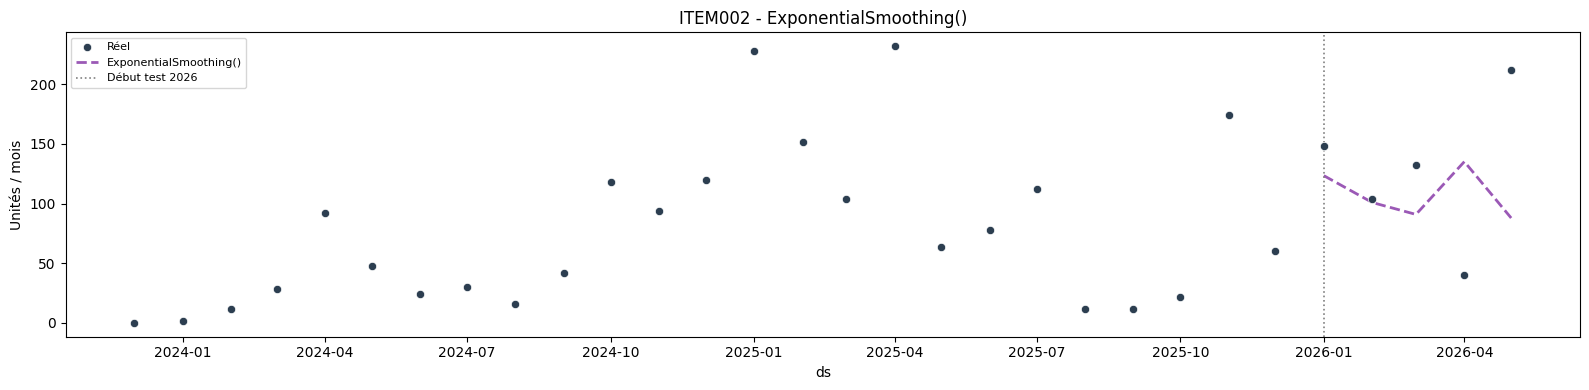

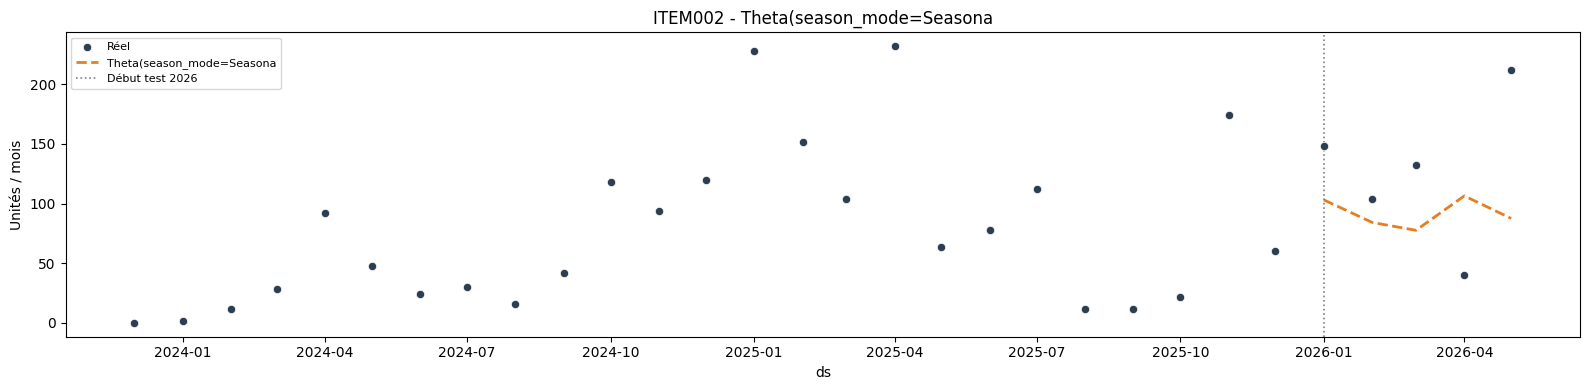

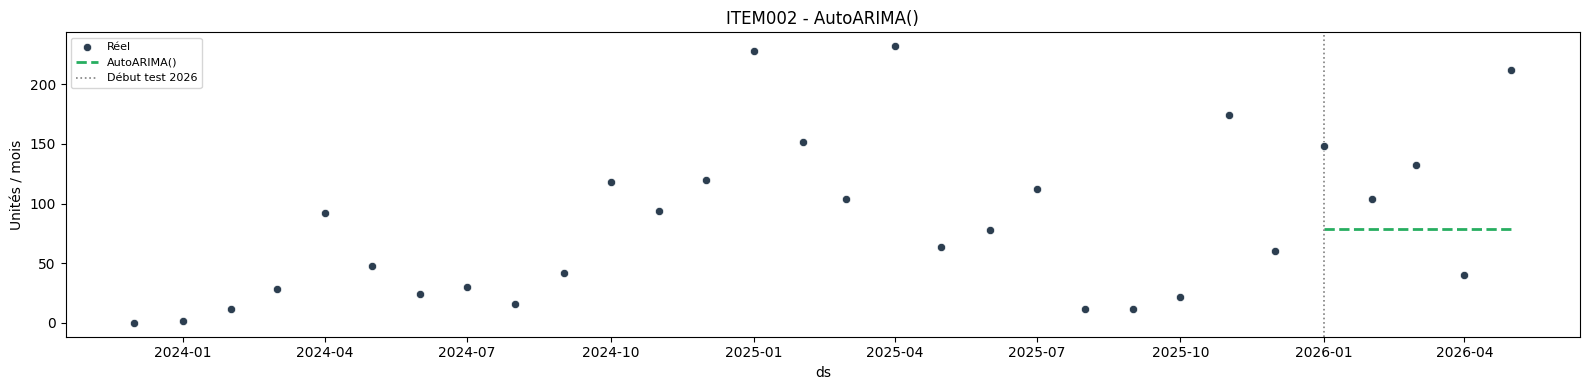

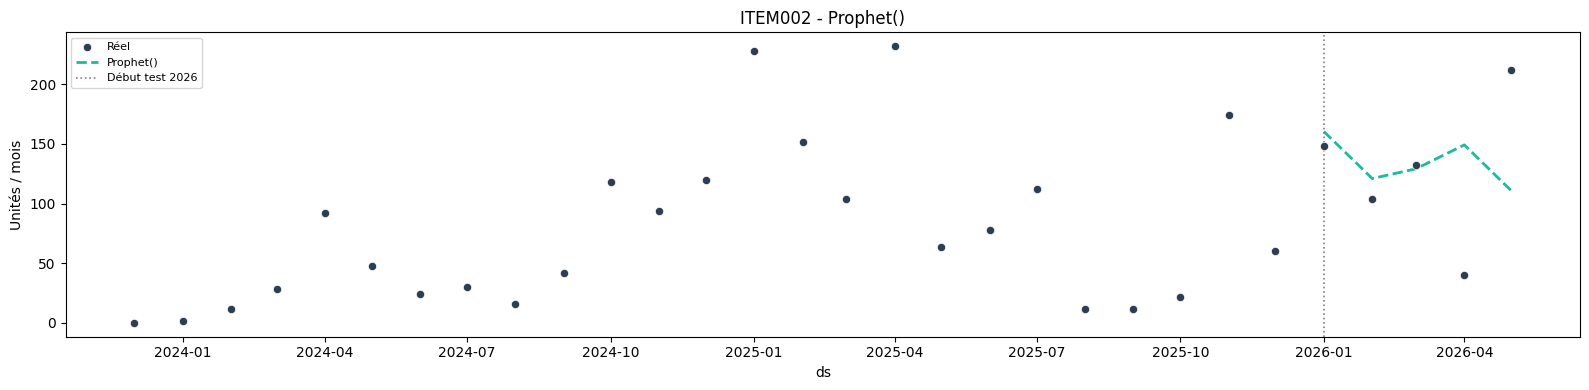

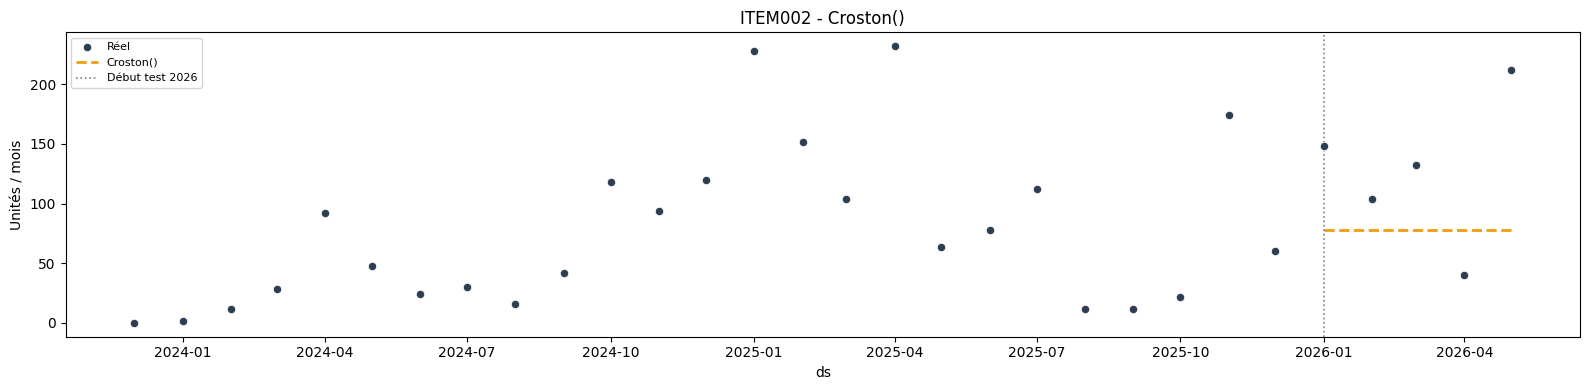

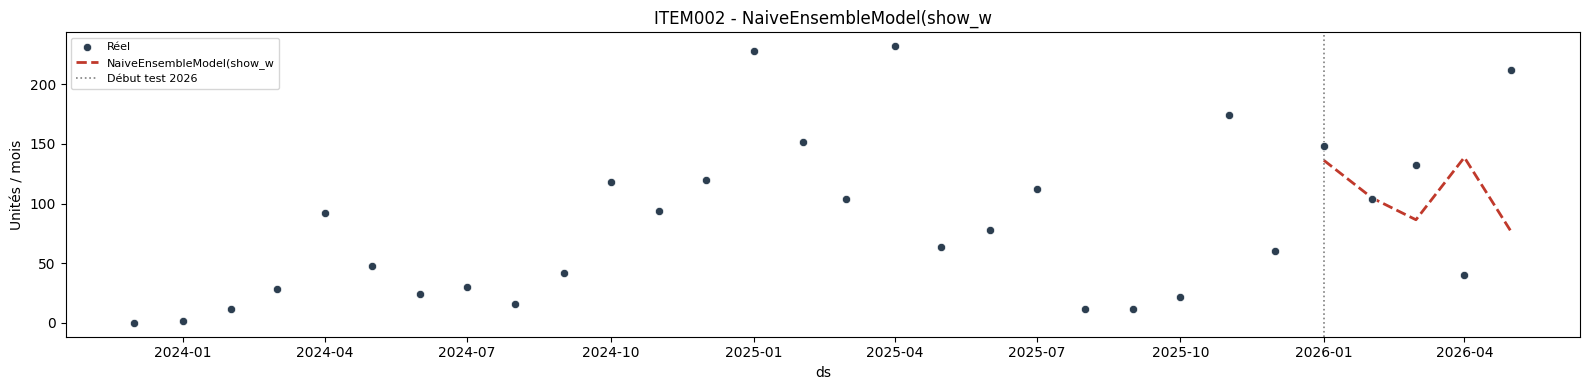

In [ ]:
couleurs_modeles = ["#e74c3c","#3498db","#9b59b6","#e67e22","#27ae60","#1abc9c","#f39c12","#c0392b"]
pd_all_errors = pd.DataFrame()

for item in items:
    y    = data[item].dropna()
    skip = bool((y[-TEST_N_POINTS:] == 0).any())

    print(f"\n{'='*55}")
    print(f"  {item}  ({len(y)} mois | {int((y==0).sum())} mois à 0)")
    if skip:
        print(f"  Note : zéros dans test => MAPE=NaN, utiliser wMAPE et RMSSE")
    print(f"{'='*55}")

    y_ts = TimeSeries.from_series(y)
    train, test = y_ts.split_before(len(y) - TEST_N_POINTS)
    test_start = test.time_index[0]

    # Baseline MM12
    mm12 = mm12_prevision(y[:-TEST_N_POINTS], TEST_N_POINTS)
    df_fcst = pd.DataFrame({"y": y, "MM12": mm12})
    errs = [calculate_test_errors(test.to_series(), mm12, train.to_series(), item, skip)]

    for model in list_models:
        m_name = str(model)[:25]
        print(f"  {m_name}...", end="  ")
        try:
            t0 = time.time()
            model.fit(train)
            fcst = model.predict(TEST_N_POINTS).to_series().clip(lower=0)
            fcst.name = m_name
            df_fcst[m_name] = fcst
            errs.append(calculate_test_errors(test.to_series(), fcst, train.to_series(), item, skip))
            print(f"ok ({time.time()-t0:.1f}s)")
        except Exception as e:
            print(f"erreur : {e}")

    pd_err = pd.concat(errs, ignore_index=True)
    pd_all_errors = pd.concat([pd_all_errors, pd_err], ignore_index=True)
    pd_err.to_csv(os.path.join(OUTPUT_DIR, f"erreurs_{item}.csv"), index=False)

    print(f"\n  Résultats {item} (tri par RMSSE) :")
    display(pd_err[["Model","MAPE","wMAPE","RMSSE","RMSE"]].sort_values("RMSSE").reset_index(drop=True))

    # Graphique combine (zoom sur fin 2024 => 2026)
    df_zoom = df_fcst[df_fcst.index >= "2024-06-01"]
    plot_forecasts(df_zoom, item, test_start)
    plt.savefig(os.path.join(OUTPUT_DIR, f"prevision_{item}.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # Graphiques individuels par modèle
    print(f"\n  Graphiques individuels - {item} :")
    for j, col in enumerate(df_fcst.columns[1:]):
        plot_modele_individuel(y, df_fcst[col], item, col, test_start,
                               couleurs_modeles[j % len(couleurs_modeles)])
        safe = col.replace("(","").replace(")","").replace(" ","_").replace("=","").replace(",","")[:30]
        plt.savefig(os.path.join(OUTPUT_DIR, f"prevision_{item}_{safe}.png"), dpi=110, bbox_inches="tight")
        plt.show()

#### Comparaison globale (wMAPE et RMSSE)

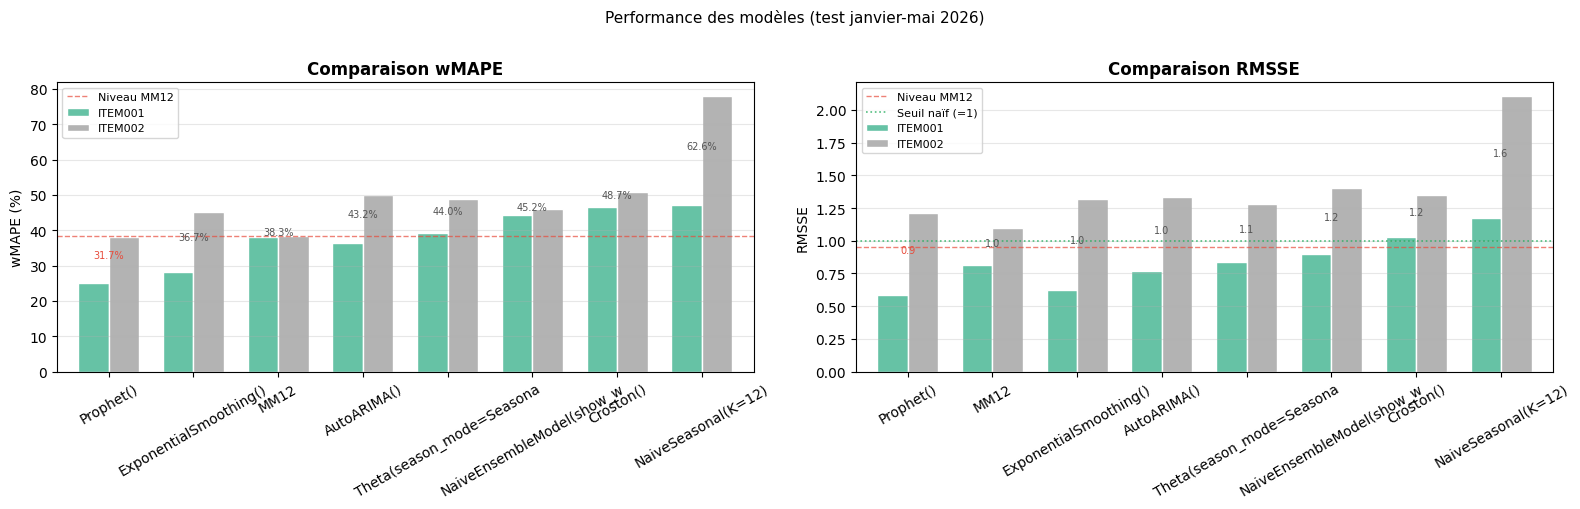

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric in zip(axes, ["wMAPE", "RMSSE"]):
    pivot = pd_all_errors.pivot_table(index="Model", columns="SeriesName", values=metric).fillna(np.nan)
    pivot["Moyenne"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("Moyenne")
    pivot.drop(columns="Moyenne").plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.72)
    for i, (idx, row) in enumerate(pivot.iterrows()):
        val = row["Moyenne"]
        if not np.isnan(val):
            ax.text(i, val + (0.5 if metric=="wMAPE" else 0.01),
                    f"{val:.1f}" + ("%" if metric=="wMAPE" else ""),
                    ha="center", fontsize=7, color="#e74c3c" if i==0 else "#555")
    mm12_row = pivot[pivot.index == "MM12"]
    if not mm12_row.empty:
        ax.axhline(mm12_row["Moyenne"].values[0], color="#e74c3c", linestyle="--",
                   linewidth=1, alpha=0.7, label="Niveau MM12")
    if metric == "RMSSE":
        ax.axhline(1.0, color="#27ae60", linestyle=":", linewidth=1.2, alpha=0.8, label="Seuil naïf (=1)")
    ax.set_title(f"Comparaison {metric}", fontsize=12, fontweight="bold")
    ax.set_ylabel(metric + (" (%)" if metric=="wMAPE" else ""))
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Performance des modèles (test janvier-mai 2026)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparaison_modeles.png"), dpi=150, bbox_inches="tight")
plt.show()

#### Résumé - meilleur modèle par produit

In [ ]:
pd_all_errors.to_csv(os.path.join(OUTPUT_DIR, "recap_erreurs.csv"), index=False)
PRIMARY = "RMSSE"

def nom_propre(m):
    return (m.replace("(K=12)", "").replace("()", "")
             .replace("(season_mode=Seasona", "").replace("(foreca", "")
             .replace("NaiveEnsembleModel", "Ensemble").strip())

# Tableau résumé : meilleur modèle par produit
resume_rows = []
for item, grp in pd_all_errors.groupby("SeriesName"):
    grp_s = grp.sort_values(PRIMARY).reset_index(drop=True)
    best  = grp_s.iloc[0]
    mm12  = grp[grp["Model"] == "MM12"].iloc[0]
    delta = (mm12[PRIMARY] - best[PRIMARY]) / mm12[PRIMARY] * 100
    resume_rows.append({
        "Produit": item,
        "Meilleur modèle": nom_propre(best["Model"]),
        "RMSSE": round(best[PRIMARY], 3),
        "wMAPE": f"{best['wMAPE']:.1f}%",
        "MM12 RMSSE": round(mm12[PRIMARY], 3),
        "MM12 wMAPE": f"{mm12['wMAPE']:.1f}%",
        "Amélioration": f"{delta:+.1f}%",
        "Verdict": "Bat MM12" if delta > 0 else "MM12 reste meilleur",
    })

df_resume = pd.DataFrame(resume_rows)
print("MEILLEUR MODELE PAR PRODUIT (métrique : RMSSE, plus bas = meilleur)\n")
display(df_resume.style.hide(axis="index"))

# Classement complet par produit
for item, grp in pd_all_errors.groupby("SeriesName"):
    grp_s = grp.sort_values(PRIMARY).reset_index(drop=True)
    tbl = grp_s[["Model", "RMSSE", "wMAPE", "RMSE"]].copy()
    tbl["Model"] = tbl["Model"].map(nom_propre)
    tbl["wMAPE"] = tbl["wMAPE"].map(lambda x: f"{x:.1f}%" if not np.isnan(x) else "N/A")
    print(f"\nClassement complet - {item}")
    display(
        tbl.style
           .hide(axis="index")
           .format({"RMSSE": "{:.3f}", "RMSE": "{:.1f}"})
    )

MEILLEUR MODELE PAR PRODUIT (métrique : RMSSE, plus bas = meilleur)



Produit,Meilleur modèle,RMSSE,wMAPE,MM12 RMSSE,MM12 wMAPE,Amélioration,Verdict
ITEM001,Prophet,0.583000,25.2%,0.812000,38.2%,+28.2%,Bat MM12
ITEM002,MM12,1.094000,38.3%,1.094000,38.3%,+0.0%,MM12 reste meilleur



Classement complet - ITEM001


Model,RMSSE,wMAPE,RMSE
Prophet,0.583,25.2%,38.3
ExponentialSmoothing,0.620,28.2%,40.7
AutoARIMA,0.766,36.4%,50.3
MM12,0.812,38.2%,53.3
Theta,0.840,39.3%,55.1
Ensemble(show_w,0.899,44.4%,59.0
Croston,1.026,46.7%,67.3
NaiveSeasonal,1.172,47.2%,76.9



Classement complet - ITEM002


Model,RMSSE,wMAPE,RMSE
MM12,1.094,38.3%,60.7
Prophet,1.212,38.1%,67.2
Theta,1.281,48.7%,71.1
ExponentialSmoothing,1.318,45.3%,73.1
AutoARIMA,1.333,50.1%,74.0
Croston,1.348,50.7%,74.8
Ensemble(show_w,1.403,45.9%,77.9
NaiveSeasonal,2.105,78.0%,116.8


---
# Étape 3 : Prévision finale + Politique de stock

**Objectif :** prévoir la demande de **juin à décembre 2026** (les 7 mois non encore
réalisés) avec le meilleur modèle, puis calculer les niveaux de stock recommandés.

**Stock de sécurité :** base sur le RMSE des erreurs de prévision du modèle sur le
test 2026 (mesure l'incertitude réelle du modèle choisi) :
```
stock_securite = z * RMSE * racine(delai)
stock_cible    = demande_prevue * delai + stock_securite
```

#### Configuration

In [ ]:
# Meilleur modèle identifié à l'étape 2
# Avec le test 2026 réel, Prophet gagne sur l'ITEM001
# Options : "Prophet", "ExponentialSmoothing", "Theta", "AutoARIMA", "Croston", "MM12"
MEILLEUR_MODELES_PAR_ITEM = {
    "ITEM001": "Prophet",
    "ITEM002": "MM12",  # ou le vrai meilleur selon vos résultats
}

# Deuxième meilleur modèle pour ITEM002 (pour comparaison)
SECOND_MODELE_ITEM002 = "Prophet"

HORIZON_FINAL   = 7      # juin à décembre 2026
Z_SCORE         = 1.645  # 95% de niveau de service (2.054=98%, 2.326=99%)
LEAD_TIME       = 1      # délai de réapprovisionnement (mois)

print(f"Modèles retenus :")
for item, modele in MEILLEUR_MODELES_PAR_ITEM.items():
    print(f"  {item} : {modele}")
print(f"Scenario alternatif ITEM002 : {SECOND_MODELE_ITEM002}")
print(f"Horizon final : {HORIZON_FINAL} mois (juin-décembre 2026)")
print(f"Niv. service  : {Z_SCORE/1.645*95:.0f}%  délai {LEAD_TIME} mois")

Modèles retenus :
  ITEM001 : Prophet
  ITEM002 : MM12
Scenario alternatif ITEM002 : Prophet
Horizon final : 7 mois (juin-décembre 2026)
Niv. service  : 95%  délai 1 mois


#### Fonctions

In [ ]:
def get_model(nom):
    return {
        "NaiveSeasonal":        NaiveSeasonal(K=12),
        "ExponentialSmoothing": ExponentialSmoothing(),
        "Theta":                Theta(season_mode=SeasonalityMode.ADDITIVE),
        "AutoARIMA":            AutoARIMA(),
        "Prophet":              Prophet(yearly_seasonality=True),
        "Croston":              Croston(),
    }.get(nom)


def calculer_stock_cible(rmse_modele, fcst_futur, z=Z_SCORE, lead_time=LEAD_TIME):
    """
    Stock de sécurité base sur le RMSE des erreurs du modèle (mesuré sur le test 2026).
    """
    ss = z * rmse_modele * np.sqrt(lead_time)
    rows = []
    for date, d_hat in fcst_futur.items():
        d_hat = max(0, d_hat)
        rows.append({
            "Mois": date.strftime("%Y-%m"), "Date": date,
            "Demande_Prevue": round(d_hat, 1),
            "RMSE_Modele": round(rmse_modele, 2),
            "Stock_Securite": round(ss, 1),
            "Dem_Delai": round(d_hat * lead_time, 1),
            "Stock_Cible": round(d_hat * lead_time + ss, 1),
        })
    return pd.DataFrame(rows).set_index("Date")


def inventory_simulation(demand_series, target_series, init_inv, lead_time):
    """Simulation politique (s,S) dynamique. Retourne (ending_inv, fill_rate, avg_inv)."""
    n   = len(demand_series)
    dem = demand_series.reset_index(drop=True)
    tgt = pd.Series(target_series).reset_index(drop=True)
    dem.index = tgt.index = range(1, n+1)
    inv = pd.DataFrame(index=range(1, n+1),
                       columns=["Start","Receipt","Demand","End","Order","Unfilled"], dtype=float)
    inv["Receipt"] = 0.0; inv["Demand"] = dem; inv.loc[1, "Start"] = init_inv
    td = tf = 0.0
    for t in range(1, n+1):
        s = tgt.loc[t]
        if t > 1: inv.loc[t,"Start"] = max(0, inv.loc[t-1,"End"])
        avail = inv.loc[t,"Start"] + inv.loc[t,"Receipt"]; d = inv.loc[t,"Demand"]
        filled = min(avail, d); inv.loc[t,"End"] = avail - filled; inv.loc[t,"Unfilled"] = d - filled
        td += d; tf += filled
        it = inv.loc[t+1:t+lead_time-1,"Receipt"].sum() if t+lead_time-1 <= n else 0
        if inv.loc[t,"End"] + it < s:
            q = s - (inv.loc[t,"End"] + it); inv.loc[t,"Order"] = q
            if t + lead_time <= n: inv.loc[t+lead_time,"Receipt"] += q
        else:
            inv.loc[t,"Order"] = 0.0
    return inv["End"], (tf/td*100 if td > 0 else 0), inv["End"].mean()

print("Fonctions définies")

Fonctions définies


#### Pipeline : prévision juin-décembre 2026 + stocks
Le RMSE utilisé pour le stock de sécurité vient des erreurs du modèle sur le test
janvier-mai 2026 (récuperé depuis recap_erreurs.csv).

In [ ]:
recap     = pd.read_csv(os.path.join(OUTPUT_DIR, "recap_erreurs.csv"))
resultats = {}

for item in items:
    y = data[item].dropna()
    print(f"\n{'='*50}\n  {item}\n{'='*50}")

    if item == "ITEM002":
        modeles_a_tester = {
            "Scenario 1 - MM12":                     "MM12",
            f"Scenario 2 - {SECOND_MODELE_ITEM002}":  SECOND_MODELE_ITEM002,
        }
    else:
        modele_principal = MEILLEUR_MODELES_PAR_ITEM[item]
        modeles_a_tester = {
            f"Scenario principal - {modele_principal}": modele_principal,
        }

    resultats[item] = {}

    for label, nom_modele in modeles_a_tester.items():
        print(f"\n  --- {label} ---")

        row = recap[(recap["SeriesName"] == item) &
                    (recap["Model"].str.startswith(nom_modele[:8]))]
        rmse_modele = float(row["RMSE"].values[0]) if len(row) > 0 else float(y.std())
        print(f"  RMSE du modèle (test 2026) : {rmse_modele:.1f}")

        # Prévision selon le modèle
        if nom_modele == "MM12":
            fcst_futur = mm12_prevision(y, HORIZON_FINAL)
            fcst_futur.name = "MM12"
        else:
            m = get_model(nom_modele)
            m.fit(TimeSeries.from_series(y))
            fcst_futur = m.predict(HORIZON_FINAL).to_series().clip(lower=0)
            fcst_futur.name = nom_modele

        df_inv = calculer_stock_cible(rmse_modele, fcst_futur)
        df_inv["Mois"] = df_inv.index.strftime("%Y-%m")

        y_test_2026 = y[-TEST_N_POINTS:]
        init_inv    = float(df_inv["Stock_Cible"].mean() * 1.2)
        tgt_sim     = pd.Series([df_inv["Stock_Cible"].mean()] * len(y_test_2026), dtype=float)
        ending_inv, fill_rate, avg_inv = inventory_simulation(
            y_test_2026, tgt_sim, init_inv, LEAD_TIME)

        resultats[item][label] = (fcst_futur, df_inv, fill_rate, avg_inv, ending_inv)

        print(f"\n  Prévision juin-décembre 2026 :")
        print(fcst_futur.round(1).to_string())
        print(f"\n  Stocks cibles :")
        display(df_inv[["Mois","Demande_Prevue","RMSE_Modele","Stock_Securite","Stock_Cible"]])
        print(f"  Simulation => taux remplissage {fill_rate:.1f}% | inv moyen {avg_inv:.1f}")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



  ITEM001

  --- Scenario principal - Prophet ---
  RMSE du modèle (test 2026) : 38.3

  Prévision juin-décembre 2026 :
ds
2026-06-01    129.2
2026-07-01     84.9
2026-08-01    100.4
2026-09-01    122.5
2026-10-01    169.8
2026-11-01     97.3
2026-12-01     91.9
Freq: MS

  Stocks cibles :


,Mois,Demande_Prevue,RMSE_Modele,Stock_Securite,Stock_Cible
Date,,,,,
2026-06-01,2026-06,129.2,38.29,63.0,192.2
2026-07-01,2026-07,84.9,38.29,63.0,147.9
2026-08-01,2026-08,100.4,38.29,63.0,163.4
2026-09-01,2026-09,122.5,38.29,63.0,185.5
2026-10-01,2026-10,169.8,38.29,63.0,232.8
2026-11-01,2026-11,97.3,38.29,63.0,160.3
2026-12-01,2026-12,91.9,38.29,63.0,154.9


  Simulation => taux remplissage 99.5% | inv moyen 52.6

  ITEM002

  --- Scenario 1 - MM12 ---
  RMSE du modèle (test 2026) : 60.7

  Prévision juin-décembre 2026 :
2026-06-01    92.2
2026-07-01    92.2
2026-08-01    92.2
2026-09-01    92.2
2026-10-01    92.2
2026-11-01    92.2
2026-12-01    92.2
Freq: MS

  Stocks cibles :


,Mois,Demande_Prevue,RMSE_Modele,Stock_Securite,Stock_Cible
Date,,,,,
2026-06-01,2026-06,92.2,60.73,99.9,192.1
2026-07-01,2026-07,92.2,60.73,99.9,192.1
2026-08-01,2026-08,92.2,60.73,99.9,192.1
2026-09-01,2026-09,92.2,60.73,99.9,192.1
2026-10-01,2026-10,92.2,60.73,99.9,192.1
2026-11-01,2026-11,92.2,60.73,99.9,192.1
2026-12-01,2026-12,92.2,60.73,99.9,192.1


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


  Simulation => taux remplissage 96.9% | inv moyen 76.6

  --- Scenario 2 - Prophet ---
  RMSE du modèle (test 2026) : 67.2

  Prévision juin-décembre 2026 :
ds
2026-06-01    109.7
2026-07-01    102.0
2026-08-01     96.9
2026-09-01     95.3
2026-10-01    136.1
2026-11-01    141.8
2026-12-01    119.4
Freq: MS

  Stocks cibles :


,Mois,Demande_Prevue,RMSE_Modele,Stock_Securite,Stock_Cible
Date,,,,,
2026-06-01,2026-06,109.7,67.24,110.6,220.3
2026-07-01,2026-07,102.0,67.24,110.6,212.6
2026-08-01,2026-08,96.9,67.24,110.6,207.5
2026-09-01,2026-09,95.3,67.24,110.6,205.9
2026-10-01,2026-10,136.1,67.24,110.6,246.7
2026-11-01,2026-11,141.8,67.24,110.6,252.5
2026-12-01,2026-12,119.4,67.24,110.6,230.0


  Simulation => taux remplissage 100.0% | inv moyen 106.9


#### Graphiques - Prévision finale + Stock cible

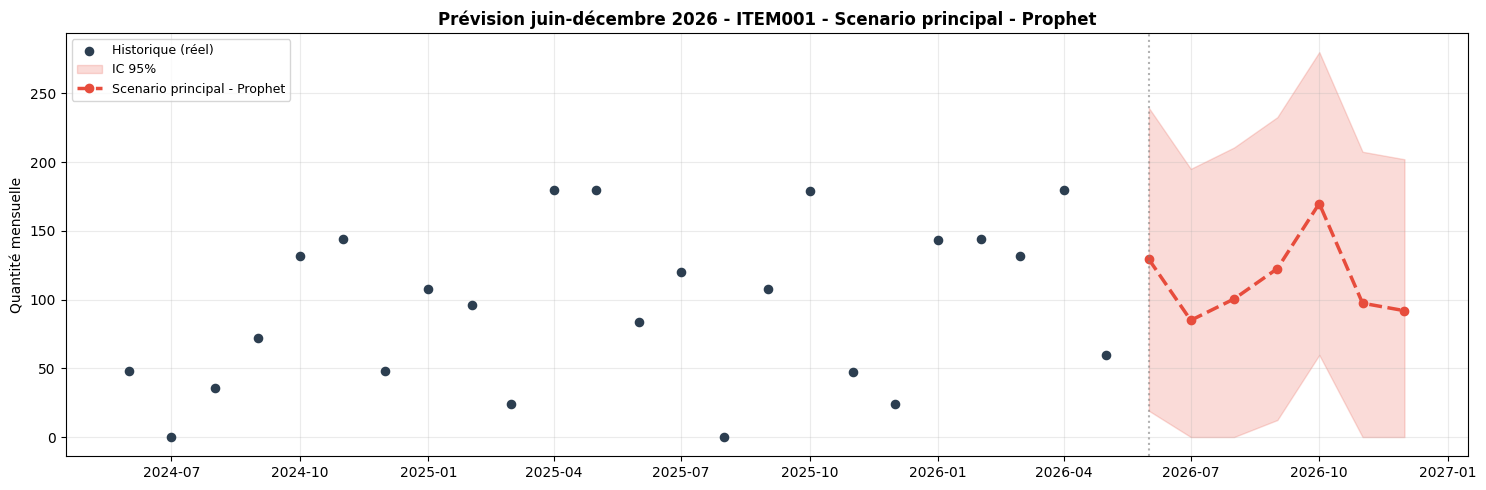

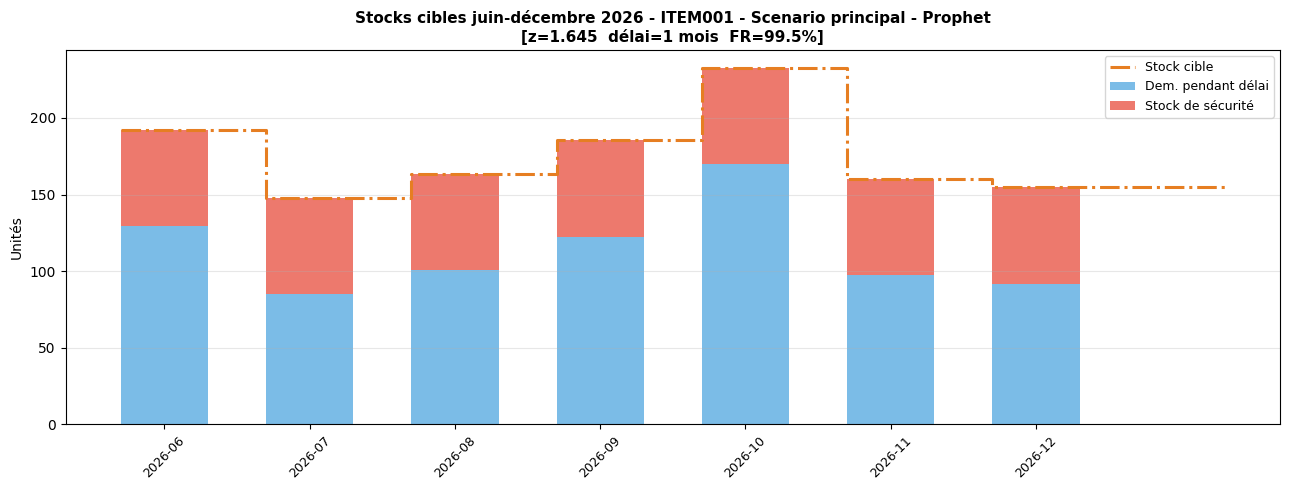

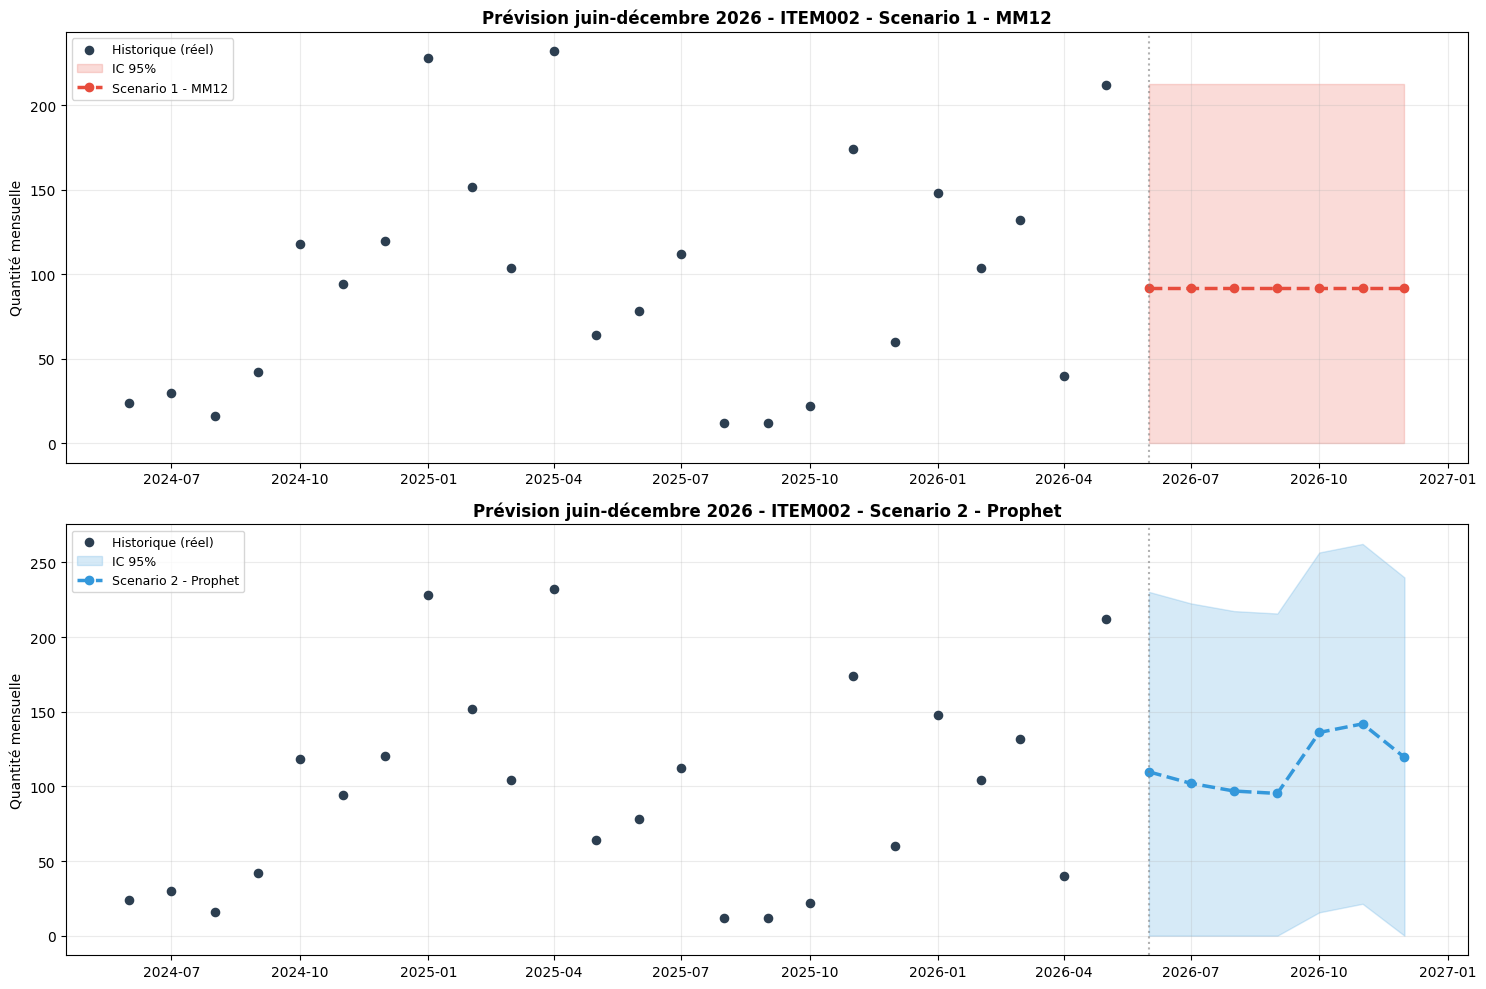

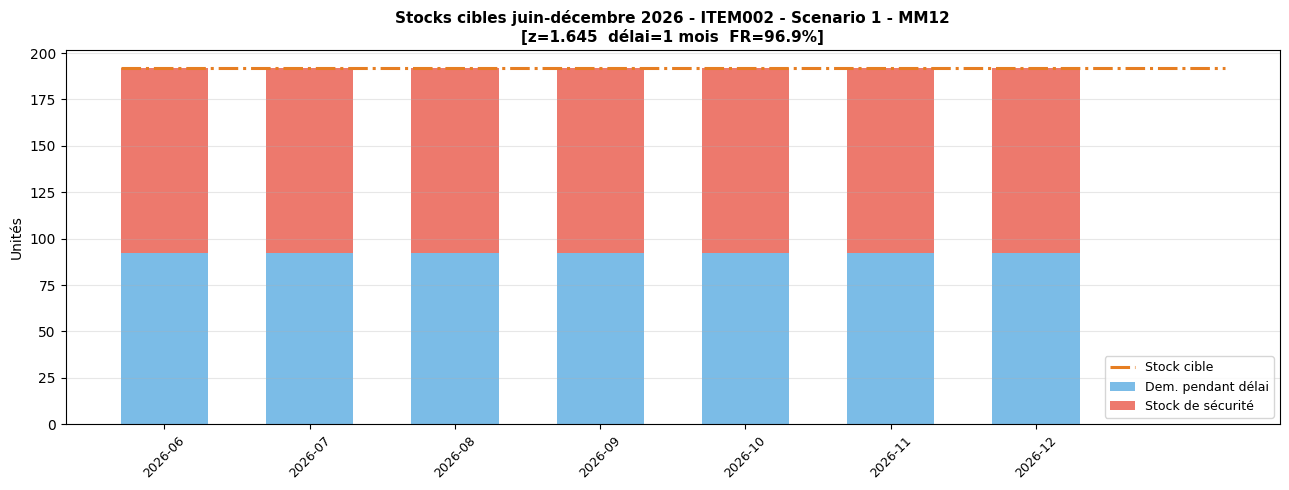

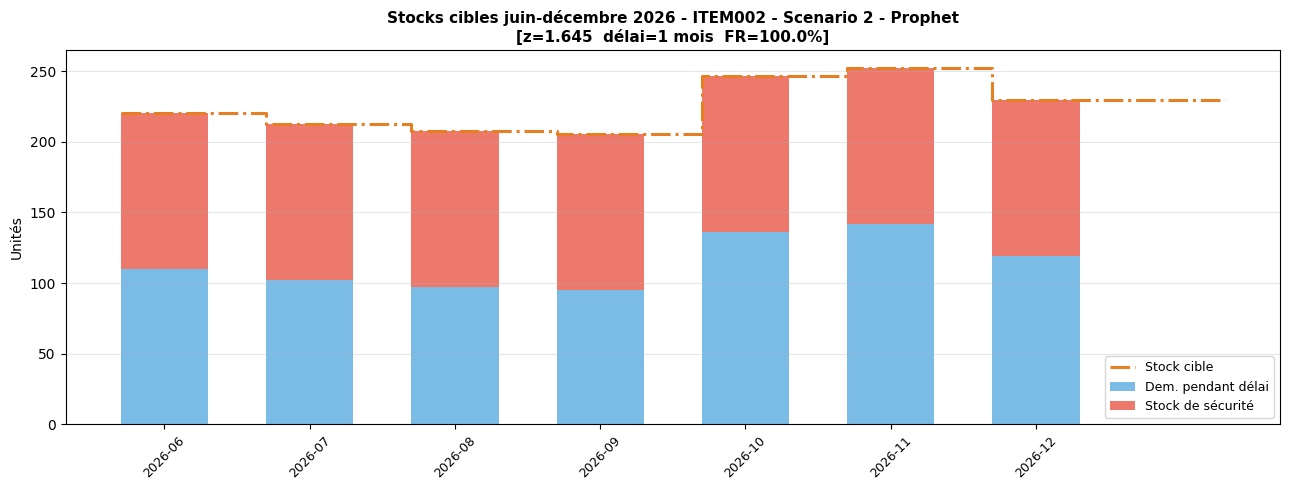

In [ ]:
for item, scenarios in resultats.items():
    y     = data[item].dropna()
    sigma = y.std()

    # Graphique prévisions : un scénario par ligne si ITEM002, sinon un seul
    fig, axes = plt.subplots(len(scenarios), 1,
                             figsize=(15, 5 * len(scenarios)),
                             squeeze=False)

    for j, (label, (fcst_futur, df_inv, fr, ai, _)) in enumerate(scenarios.items()):
        ax = axes[j][0]
        couleur = ["#e74c3c", "#3498db"][j % 2]

        # Historique
        ax.scatter(y[-24:].index, y[-24:].values,
                   label="Historique (réel)", s=35, color="#2c3e50", zorder=5)

        # Intervalle de confiance
        ax.fill_between(fcst_futur.index,
                        np.maximum(fcst_futur.values - 1.96*sigma, 0),
                        fcst_futur.values + 1.96*sigma,
                        alpha=0.2, color=couleur, label="IC 95%")

        # Prévision
        ax.plot(fcst_futur.index, fcst_futur.values,
                color=couleur, linewidth=2.5, linestyle="--",
                marker="o", markersize=6, label=label)

        ax.axvline(fcst_futur.index[0], color="gray",
                   linestyle=":", linewidth=1.5, alpha=0.6)
        ax.set_title(f"Prévision juin-décembre 2026 - {item} - {label}",
                     fontsize=12, fontweight="bold")
        ax.set_ylabel("Quantité mensuelle")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"prevision_finale_{item}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    # Graphique stock cible : un par scénario
    for label, (fcst_futur, df_inv, fr, ai, _) in scenarios.items():
        fig, ax = plt.subplots(figsize=(13, 5))
        x = range(len(df_inv))
        mois = df_inv["Mois"].tolist()

        ax.bar(x, df_inv["Dem_Delai"], color="#3498db", alpha=0.65,
               width=0.6, label="Dem. pendant délai")
        ax.bar(x, df_inv["Stock_Securite"], color="#e74c3c", alpha=0.75,
               width=0.6, bottom=df_inv["Dem_Delai"], label="Stock de sécurité")
        ax.step([xi-0.3 for xi in x] + [len(x)-0.3+0.6],
                list(df_inv["Stock_Cible"]) + [df_inv["Stock_Cible"].iloc[-1]],
                where="post", color="#e67e22", linewidth=2.2,
                linestyle="-.", label="Stock cible")

        ax.set_xticks(x)
        ax.set_xticklabels(mois, rotation=45, fontsize=9)
        ax.set_ylabel("Unités")
        ax.set_title(f"Stocks cibles juin-décembre 2026 - {item} - {label}\n"
                     f"[z={Z_SCORE}  délai={LEAD_TIME} mois  FR={fr:.1f}%]",
                     fontsize=11, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()

        safe_label = label.replace(" ", "_").replace("-","").replace("/","")[:30]
        plt.savefig(os.path.join(OUTPUT_DIR, f"stock_cible_{item}_{safe_label}.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()